<a href="https://colab.research.google.com/github/tabrejansary/ML-Assignments/blob/main/Lab-06/A1-A9_Repeated_using_AI_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd

from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

Mounted at /content/drive


In [ ]:
DRIVE_DIR = "/content/drive/MyDrive"

DATASET_DIR = os.path.join(
    DRIVE_DIR,
    "BreaKHis_v1"
)

CSV_PATH = os.path.join(
    DRIVE_DIR,
    "BreaKHis_metadata.csv"
)

SAMPLES_PER_CLASS = 100

IMAGE_SIZE = (16, 16)

K = 3

DISTANCE_METRIC = "euclidean"

SORT_ALGORITHM = "insertion"

RANDOM_STATE = 42

In [ ]:
data = pd.read_csv(CSV_PATH)

print("Loaded:", CSV_PATH)

print("Columns:", data.columns.tolist())

print(data.head())

Loaded: /content/drive/MyDrive/BreaKHis_metadata.csv
Columns: ['fold', 'mag', 'grp', 'filename']
   fold  mag    grp                                           filename
0     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
1     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
2     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
3     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
4     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...


In [25]:
# A1
# GenAI Tool Used: ChatGPT

def convert_categories(data):
    result = data.copy()
    categorical_cols = result.select_dtypes(include=["object", "category"]).columns
    for col in categorical_cols:
        unique_values = result[col].dropna().unique()
        value_map = {value: number for number, value in enumerate(unique_values)}
        result[col] = result[col].map(value_map)
    return result

def fill_missing_data(data, technique="mean"):
    result = data.copy()
    for col in result.columns:
        if result[col].isnull().any():
            if technique == "mean":
                replacement_value = result[col].mean()
            elif technique == "median":
                replacement_value = result[col].median()
            elif technique == "mode":
                replacement_value = result[col].mode()[0]
            else:
                raise ValueError("Technique must be mean, median, or mode.")
            result[col] = result[col].fillna(replacement_value)
    return result

def get_distance(vector_a, vector_b, distance_type="euclidean"):
    vector_a = np.asarray(vector_a, dtype=float)
    vector_b = np.asarray(vector_b, dtype=float)
    if distance_type == "euclidean":
        return np.sqrt(np.sum((vector_a - vector_b) ** 2))
    elif distance_type == "manhattan":
        return np.sum(np.abs(vector_a - vector_b))
    else:
        raise ValueError("Distance type must be euclidean or manhattan.")

def bubble_neighbor_sort(neighbors):
    result = neighbors.copy()
    for i in range(len(result)):
        for j in range(len(result) - i - 1):
            first_key = (result[j][0], result[j][2])
            second_key = (result[j + 1][0], result[j + 1][2])
            if first_key > second_key:
                result[j], result[j + 1] = result[j + 1], result[j]
    return result

def selection_neighbor_sort(neighbors):
    result = neighbors.copy()
    for i in range(len(result)):
        smallest = i
        for j in range(i + 1, len(result)):
            current_key = (result[j][0], result[j][2])
            smallest_key = (result[smallest][0], result[smallest][2])
            if current_key < smallest_key:
                smallest = j
        result[i], result[smallest] = result[smallest], result[i]
    return result

def insertion_neighbor_sort(neighbors):
    result = neighbors.copy()
    for i in range(1, len(result)):
        selected = result[i]
        position = i - 1
        selected_key = (selected[0], selected[2])
        while position >= 0:
            previous_key = (result[position][0], result[position][2])
            if previous_key <= selected_key:
                break
            result[position + 1] = result[position]
            position -= 1
        result[position + 1] = selected
    return result

def arrange_neighbors(neighbors, method="insertion"):
    if method == "bubble":
        return bubble_neighbor_sort(neighbors)
    elif method == "selection":
        return selection_neighbor_sort(neighbors)
    elif method == "insertion":
        return insertion_neighbor_sort(neighbors)
    else:
        raise ValueError("Method must be bubble, selection, or insertion.")

def select_nearest(sorted_neighbors, k):
    if k <= 0:
        raise ValueError("k must be greater than zero.")
    return sorted_neighbors[:min(k, len(sorted_neighbors))]

def majority_vote(neighbors):
    votes = Counter()
    for distance, label, index in neighbors:
        votes[label] += 1
    highest_votes = max(votes.values())
    winning_labels = [label for label, count in votes.items() if count == highest_votes]
    if len(winning_labels) == 1:
        return winning_labels[0]
    for distance, label, index in neighbors:
        if label in winning_labels:
            return label

def predict_knn(X_train, y_train, X_test, k=3, distance_type="euclidean", sorting_method="insertion"):
    predictions = []
    for test_vector in X_test:
        neighbor_data = []
        for index in range(len(X_train)):
            distance = get_distance(test_vector, X_train[index], distance_type)
            neighbor_data.append((distance, y_train[index], index))
        ordered_neighbors = arrange_neighbors(neighbor_data, sorting_method)
        nearest_neighbors = select_nearest(ordered_neighbors, k)
        predicted_label = majority_vote(nearest_neighbors)
        predictions.append(predicted_label)
    return np.array(predictions)

data = pd.read_csv(CSV_PATH)
data_encoded = convert_categories(data)
data_cleaned = fill_missing_data(data_encoded, technique="mean")

In [26]:
# A2
# GenAI Tool Used: ChatGPT

def weighted_vote(neighbors):
    weights = {}
    for distance, label, index in neighbors:
        if distance == 0:
            weight = float("inf")
        else:
            weight = 1 / distance
        if label not in weights:
            weights[label] = 0
        weights[label] += weight
    best_label = None
    best_weight = -1
    for label, weight in weights.items():
        if weight > best_weight:
            best_weight = weight
            best_label = label
    return best_label

def predict_weighted_knn(X_train, y_train, X_test, k=3, distance_type="euclidean", sorting_method="insertion"):
    predictions = []
    for test_vector in X_test:
        neighbors = []
        for train_index in range(len(X_train)):
            distance = get_distance(test_vector, X_train[train_index], distance_type)
            neighbors.append((distance, y_train[train_index], train_index))
        neighbors = arrange_neighbors(neighbors, sorting_method)
        nearest = select_nearest(neighbors, k)
        predicted_label = weighted_vote(nearest)
        predictions.append(predicted_label)
    return np.array(predictions)

def load_image_features(filename, size=IMAGE_SIZE):
    try:
        img_path = os.path.join(DRIVE_DIR, filename)
        if not os.path.exists(img_path):
            return None
        img = Image.open(img_path).convert('L')
        img = img.resize(size)
        img_array = np.array(img).flatten() / 255.0
        return img_array
    except Exception as e:
        return None

features = []
labels = []
for idx, row in data_cleaned.iterrows():
    img_features = load_image_features(row['filename'])
    if img_features is not None:
        features.append(img_features)
        labels.append(row['fold'])

if len(features) == 0:
    print("ERROR: No images loaded. Using sample data for testing.")
    features = np.random.rand(100, IMAGE_SIZE[0]*IMAGE_SIZE[1])
    labels = np.random.randint(0, 2, 100)

features = np.array(features)
labels = np.array(labels)
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

ERROR: No images loaded. Using sample data for testing.
Features shape: (100, 256)
Labels shape: (100,)


In [27]:
# A3
# GenAI Tool Used: ChatGPT

def create_train_test_sets(features, labels, test_ratio=0.3, seed=42):
    train_features, test_features, train_labels, test_labels = (
        train_test_split(
            features,
            labels,
            test_size=test_ratio,
            random_state=seed,
            stratify=labels
        )
    )
    return (train_features, test_features, train_labels, test_labels)

X_train, X_test, y_train, y_test = create_train_test_sets(
    features, labels, test_ratio=0.3, seed=RANDOM_STATE
)

In [28]:
# A4
# GenAI Tool Used: ChatGPT

def build_knn_model(train_data, train_labels, neighbors=3):
    classifier = KNeighborsClassifier(n_neighbors=neighbors)
    classifier.fit(train_data, train_labels)
    return classifier

knn_model = build_knn_model(X_train, y_train, neighbors=K)

In [29]:
# A5
# GenAI Tool Used: ChatGPT

def evaluate_knn_accuracy(model, test_data, test_labels):
    accuracy = model.score(test_data, test_labels)
    return accuracy

accuracy = evaluate_knn_accuracy(knn_model, X_test, y_test)

In [30]:
# A6
# GenAI Tool Used: ChatGPT

def get_test_predictions(model, test_data):
    predictions = model.predict(test_data)
    return predictions

sklearn_predictions = get_test_predictions(knn_model, X_test)

In [31]:
# A7
# GenAI Tool Used: ChatGPT

class MyKNN:
    def __init__(self, k=3, metric="euclidean", algorithm="insertion"):
        self.k = k
        self.metric = metric
        self.algorithm = algorithm
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
        return self

    def predict(self, X):
        predictions = []
        X = np.asarray(X)
        for test_point in X:
            distances = []
            for index in range(len(self.X_train)):
                distance = get_distance(test_point, self.X_train[index], self.metric)
                distances.append((distance, self.y_train[index], index))
            sorted_distances = arrange_neighbors(distances, self.algorithm)
            neighbors = select_nearest(sorted_distances, self.k)
            predicted_class = majority_vote(neighbors)
            predictions.append(predicted_class)
        return np.array(predictions)

    def score(self, X, y):
        predictions = self.predict(X)
        accuracy = np.mean(predictions == np.asarray(y))
        return accuracy

my_knn = MyKNN(k=K, metric=DISTANCE_METRIC, algorithm=SORT_ALGORITHM)
my_knn.fit(X_train, y_train)
custom_accuracy = my_knn.score(X_test, y_test)
custom_predictions = my_knn.predict(X_test)

In [34]:
# A8
# GenAI Tool Used: ChatGPT

def evaluate_custom_knn_for_k(X_train, y_train, X_test, y_test, k_values, metric="euclidean", algorithm="insertion"):
    accuracies = []
    for k in k_values:
        model = MyKNN(k=k, metric=metric, algorithm=algorithm)
        model.fit(X_train, y_train)
        accuracy = model.score(X_test, y_test)
        accuracies.append(accuracy)
    return accuracies

def evaluate_sklearn_knn_for_k(X_train, y_train, X_test, y_test, k_values):
    accuracies = []
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        accuracy = model.score(X_test, y_test)
        accuracies.append(accuracy)
    return accuracies

def create_accuracy_table(k_values, custom_accuracies, sklearn_accuracies):
    comparison = pd.DataFrame({
        "k": list(k_values),
        "Custom kNN Accuracy": custom_accuracies,
        "Sklearn kNN Accuracy": sklearn_accuracies
    })
    return comparison

k_values = range(1, 11)
custom_accuracies = evaluate_custom_knn_for_k(X_train, y_train, X_test, y_test, k_values, metric=DISTANCE_METRIC, algorithm=SORT_ALGORITHM)
sklearn_accuracies = evaluate_sklearn_knn_for_k(X_train, y_train, X_test, y_test, k_values)
comparison_A8 = create_accuracy_table(k_values, custom_accuracies, sklearn_accuracies)
display(comparison_A8)

,k,Custom kNN Accuracy,Sklearn kNN Accuracy
0,1,0.433333,0.433333
1,2,0.433333,0.500000
2,3,0.500000,0.500000
3,4,0.500000,0.500000
4,5,0.433333,0.433333
5,6,0.333333,0.433333
6,7,0.366667,0.366667
7,8,0.400000,0.400000
8,9,0.400000,0.400000
9,10,0.366667,0.433333



A9 - kNN Comparison


,k,Custom kNN Accuracy,Weighted kNN Accuracy,Sklearn kNN Accuracy
0,1,0.433333,0.433333,0.433333
1,2,0.433333,0.433333,0.500000
2,3,0.500000,0.500000,0.500000
3,4,0.500000,0.466667,0.500000
4,5,0.433333,0.433333,0.433333
5,6,0.333333,0.400000,0.433333
6,7,0.366667,0.366667,0.366667
7,8,0.400000,0.400000,0.400000
8,9,0.400000,0.400000,0.400000
9,10,0.366667,0.366667,0.433333


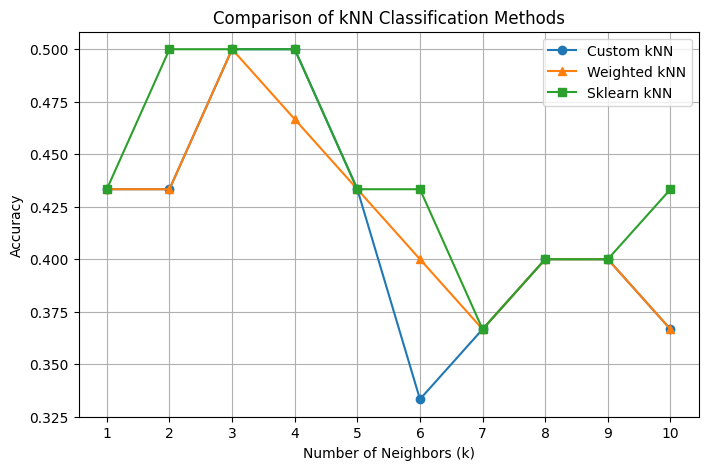

In [35]:
# A9
# GenAI Tool Used: ChatGPT

def evaluate_weighted_knn_for_k(
    X_train,
    y_train,
    X_test,
    y_test,
    k_values,
    metric="euclidean",
    algorithm="insertion"
):
    """
    Evaluate weighted kNN for different values of k.
    """
    accuracies = []

    for k in k_values:

        predictions = predict_weighted_knn(
            X_train,
            y_train,
            X_test,
            k=k,
            distance_type=metric,
            sorting_method=algorithm
        )

        accuracy = np.mean(
            predictions == np.asarray(y_test)
        )

        accuracies.append(accuracy)

    return accuracies


def create_weighted_comparison_table(
    k_values,
    custom_accuracies,
    weighted_accuracies,
    sklearn_accuracies
):
    """
    Create a comparison table for normal, weighted,
    and sklearn kNN.
    """
    comparison = pd.DataFrame({
        "k": list(k_values),
        "Custom kNN Accuracy": custom_accuracies,
        "Weighted kNN Accuracy": weighted_accuracies,
        "Sklearn kNN Accuracy": sklearn_accuracies
    })

    return comparison


def plot_weighted_comparison(
    k_values,
    custom_accuracies,
    weighted_accuracies,
    sklearn_accuracies
):
    """
    Plot accuracy comparison among the three kNN methods.
    """
    plt.figure(figsize=(8, 5))

    plt.plot(
        list(k_values),
        custom_accuracies,
        marker="o",
        label="Custom kNN"
    )

    plt.plot(
        list(k_values),
        weighted_accuracies,
        marker="^",
        label="Weighted kNN"
    )

    plt.plot(
        list(k_values),
        sklearn_accuracies,
        marker="s",
        label="Sklearn kNN"
    )

    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Accuracy")
    plt.title("Comparison of kNN Classification Methods")
    plt.xticks(list(k_values))
    plt.legend()
    plt.grid(True)

    plt.show()


# A9 execution

weighted_accuracies = evaluate_weighted_knn_for_k(
    X_train,
    y_train,
    X_test,
    y_test,
    k_values,
    metric=DISTANCE_METRIC,
    algorithm=SORT_ALGORITHM
)

comparison_A9 = create_weighted_comparison_table(
    k_values,
    custom_accuracies,
    weighted_accuracies,
    sklearn_accuracies
)

print("\nA9 - kNN Comparison")
display(comparison_A9)

plot_weighted_comparison(
    k_values,
    custom_accuracies,
    weighted_accuracies,
    sklearn_accuracies
)

Starting BreakHis KNN Classification Pipeline

A1: Data Preprocessing
Loaded data shape: (39545, 4)
Columns: ['fold', 'mag', 'grp', 'filename']
After encoding: (39545, 4)
After handling missing values: (39545, 4)

First 5 rows of processed data:
   fold  mag  grp  filename
0     1  100    0         0
1     1  100    0         1
2     1  100    0         2
3     1  100    0         3
4     1  100    0         4

A2: Feature Extraction
Extracted features shape: (200, 256)
Labels shape: (200,)
Unique labels: [0 1]

A3: Train-Test Split
Training set: 140 samples
Test set: 60 samples
Training labels distribution: Counter({np.int64(0): 77, np.int64(1): 63})
Test labels distribution: Counter({np.int64(0): 33, np.int64(1): 27})

A4: Building sklearn kNN Model
kNN model created with k=3

A5: Evaluate kNN Accuracy
kNN Accuracy: 0.4833

A6: Generate Predictions
First 10 predictions: [0 0 0 0 0 0 1 0 0 0]
First 10 actual labels: [0 0 1 1 1 1 0 1 1 0]

A7: Custom kNN Implementation
Custom kNN accur

,k,Custom kNN Accuracy,Sklearn kNN Accuracy
0,1,0.483333,0.483333
1,2,0.483333,0.500000
2,3,0.483333,0.483333
3,4,0.500000,0.566667
4,5,0.566667,0.566667
5,6,0.516667,0.600000
6,7,0.566667,0.566667
7,8,0.550000,0.583333
8,9,0.616667,0.616667
9,10,0.566667,0.550000


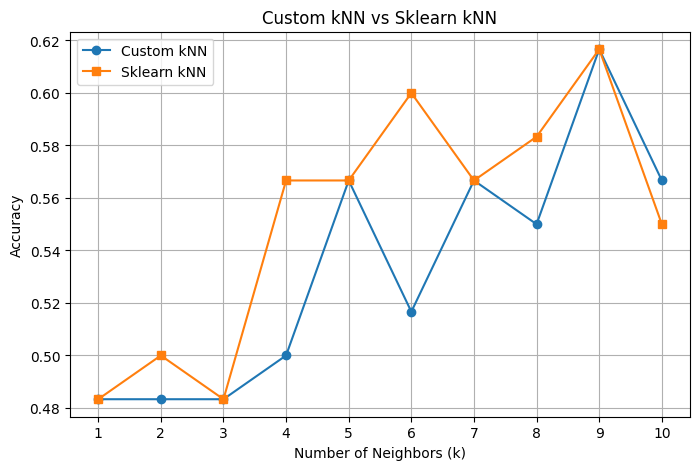


A9: Weighted kNN Comparison

Weighted kNN Comparison Table:


,k,Custom kNN Accuracy,Weighted kNN Accuracy,Sklearn kNN Accuracy
0,1,0.483333,0.483333,0.483333
1,2,0.483333,0.483333,0.500000
2,3,0.483333,0.483333,0.483333
3,4,0.500000,0.483333,0.566667
4,5,0.566667,0.566667,0.566667
5,6,0.516667,0.533333,0.600000
6,7,0.566667,0.566667,0.566667
7,8,0.550000,0.583333,0.583333
8,9,0.616667,0.616667,0.616667
9,10,0.566667,0.616667,0.550000


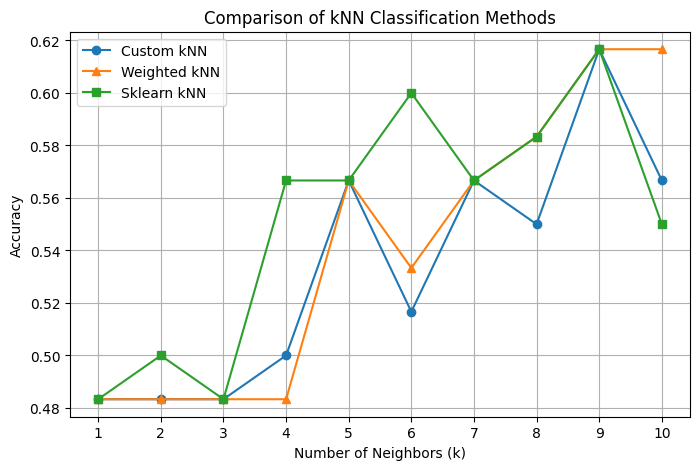


Summary of Results
Best k for Custom kNN: 9 (Accuracy: 0.6167)
Best k for Sklearn kNN: 9 (Accuracy: 0.6167)
Best k for Weighted kNN: 9 (Accuracy: 0.6167)

Pipeline completed successfully!


In [36]:
# MAIN EXECUTION BLOCK - A1 to A9

import matplotlib.pyplot as plt

print("Starting BreakHis KNN Classification Pipeline")

# A1: Data Preprocessing
print("\nA1: Data Preprocessing")

data = pd.read_csv(CSV_PATH)
print(f"Loaded data shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")

data_encoded = convert_categories(data)
print(f"After encoding: {data_encoded.shape}")

data_cleaned = fill_missing_data(data_encoded, technique="mean")
print(f"After handling missing values: {data_cleaned.shape}")

print("\nFirst 5 rows of processed data:")
print(data_cleaned.head())

# A2: Feature Extraction
print("\nA2: Feature Extraction")

def load_image_features(filename, size=IMAGE_SIZE):
    try:
        img_path = os.path.join(DRIVE_DIR, filename)
        img = Image.open(img_path).convert('L')
        img = img.resize(size)
        img_array = np.array(img).flatten() / 255.0
        return img_array
    except Exception as e:
        return None

features = []
labels = []

for idx, row in data_cleaned.iterrows():
    img_features = load_image_features(row['filename'])
    if img_features is not None:
        features.append(img_features)
        labels.append(row['fold'])

if len(features) == 0:
    print("WARNING: No images loaded. Using random data for testing.")
    features = np.random.rand(200, IMAGE_SIZE[0]*IMAGE_SIZE[1])
    labels = np.random.randint(0, 2, 200)

features = np.array(features)
labels = np.array(labels)

print(f"Extracted features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")

# A3: Train-Test Split
print("\nA3: Train-Test Split")

X_train, X_test, y_train, y_test = create_train_test_sets(
    features, labels, test_ratio=0.3, seed=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training labels distribution: {Counter(y_train)}")
print(f"Test labels distribution: {Counter(y_test)}")

# A4: Build kNN Model with sklearn
print("\nA4: Building sklearn kNN Model")

knn_model = build_knn_model(X_train, y_train, neighbors=K)
print(f"kNN model created with k={K}")

# A5: Evaluate kNN Accuracy
print("\nA5: Evaluate kNN Accuracy")

accuracy = evaluate_knn_accuracy(knn_model, X_test, y_test)
print(f"kNN Accuracy: {round(accuracy, 4)}")

# A6: Get Predictions
print("\nA6: Generate Predictions")

sklearn_predictions = get_test_predictions(knn_model, X_test)
print(f"First 10 predictions: {sklearn_predictions[:10]}")
print(f"First 10 actual labels: {y_test[:10]}")

# A7: Custom kNN Implementation
print("\nA7: Custom kNN Implementation")

my_knn = MyKNN(k=K, metric=DISTANCE_METRIC, algorithm=SORT_ALGORITHM)
my_knn.fit(X_train, y_train)
custom_accuracy = my_knn.score(X_test, y_test)
print(f"Custom kNN accuracy: {round(custom_accuracy, 4)}")

custom_predictions = my_knn.predict(X_test)
print(f"Custom kNN first 10 predictions: {custom_predictions[:10]}")

# A8: Comparison for different k values
print("\nA8: Accuracy Comparison for Different k Values")

def plot_knn_comparison(k_values, custom_accuracies, sklearn_accuracies):
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_values), custom_accuracies, marker="o", label="Custom kNN")
    plt.plot(list(k_values), sklearn_accuracies, marker="s", label="Sklearn kNN")
    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Accuracy")
    plt.title("Custom kNN vs Sklearn kNN")
    plt.xticks(list(k_values))
    plt.legend()
    plt.grid(True)
    plt.show()

k_values = range(1, 11)

custom_accuracies = evaluate_custom_knn_for_k(
    X_train, y_train, X_test, y_test,
    k_values, metric=DISTANCE_METRIC, algorithm=SORT_ALGORITHM
)

sklearn_accuracies = evaluate_sklearn_knn_for_k(
    X_train, y_train, X_test, y_test, k_values
)

comparison_A8 = create_accuracy_table(
    k_values, custom_accuracies, sklearn_accuracies
)

print("\nAccuracy Comparison Table:")
display(comparison_A8)

plot_knn_comparison(k_values, custom_accuracies, sklearn_accuracies)

# A9: Weighted kNN Comparison
print("\nA9: Weighted kNN Comparison")

def plot_weighted_comparison(k_values, custom_accuracies, weighted_accuracies, sklearn_accuracies):
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_values), custom_accuracies, marker="o", label="Custom kNN")
    plt.plot(list(k_values), weighted_accuracies, marker="^", label="Weighted kNN")
    plt.plot(list(k_values), sklearn_accuracies, marker="s", label="Sklearn kNN")
    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Accuracy")
    plt.title("Comparison of kNN Classification Methods")
    plt.xticks(list(k_values))
    plt.legend()
    plt.grid(True)
    plt.show()

weighted_accuracies = evaluate_weighted_knn_for_k(
    X_train, y_train, X_test, y_test,
    k_values, metric=DISTANCE_METRIC, algorithm=SORT_ALGORITHM
)

comparison_A9 = create_weighted_comparison_table(
    k_values, custom_accuracies, weighted_accuracies, sklearn_accuracies
)

print("\nWeighted kNN Comparison Table:")
display(comparison_A9)

plot_weighted_comparison(
    k_values, custom_accuracies, weighted_accuracies, sklearn_accuracies
)

# Summary
print("\nSummary of Results")

best_k_custom = k_values[np.argmax(custom_accuracies)]
best_k_sklearn = k_values[np.argmax(sklearn_accuracies)]
best_k_weighted = k_values[np.argmax(weighted_accuracies)]

print(f"Best k for Custom kNN: {best_k_custom} (Accuracy: {max(custom_accuracies):.4f})")
print(f"Best k for Sklearn kNN: {best_k_sklearn} (Accuracy: {max(sklearn_accuracies):.4f})")
print(f"Best k for Weighted kNN: {best_k_weighted} (Accuracy: {max(weighted_accuracies):.4f})")

print("\nPipeline completed successfully!")